# Relacion 1b Nanoelectrónica

### Ejercicio 4

**Calcular y representar nuevamente los cinco primeros niveles de
energía ($𝐸_i$) permitidos y las funciones de onda asociadas para el pozo de
potencial de profundidad 2.5eV y anchura L=4nm. En este caso la solución
debe obtenerse discretizando el Hamiltoniano usando un método de
diferencias finitas, tal y como se explicará en clase (No hacer hasta que
se explique en clase).**


Para resolverlo impondré condiciones de contorno tipo Dirichlet. Asumiré que la penetración de la onda es muy pequeña, por lo que a una distancia de L/2 del pozo la onda será prácticamente nula, por lo que la haré 0.

Condiciones dirichlet:
$$
\Psi(x_{min}) = \Psi(x_{max}) = 0
$$

In [2]:
## LIBRERIAS

import numpy as np
import matplotlib.pyplot as plt

In [13]:
### CODIGO PARA EJECUTAR VARIABLES #######################



##### VARIABLES #####

L = 4 #nm           #ANCHURA
V0 = 3 #ev          #Profundidad del pozo

N = 1000            #Cantidad de puntos de divisiones
x_min = -L
x_max = L           #Dimensiones donde integraremos

numestados = 5      #Numero de estados que queremos calcular  


##### CONSTANTES ####

hbar = 197.33   ## eV nm

m = 511000      #eV (masa electrón)



#Creo el linspace de puntos y el espaciado
x = np.linspace(x_min, x_max, N)
dx = x[1] - x[0]

In [5]:
### DEFINIR EL POZO ################

V = np.zeros(N)

for i in range(N):
    if abs(x[i]) < L/2:
        V[i] = 0.0
    
    else:
        V[i] = V0

In [11]:
### DEFINIR EL HAMILTONIANO ####################

from scipy.sparse.linalg import eigsh #Librería recomendada en clase
from scipy.sparse import diags

coefi = hbar**2 / (2*m*dx**2)

#Defino la matriz con la diagonal y el offset

#Condiciones de Dirichlet: 
Vinterior=V[1:-1] #Impongo que el los puntos finales la onda sea 0

#Esto tendrá dimension N-2, por tanto trabajo con un n que sea N-2

N2 = N-2

diagonal = 2*coefi + Vinterior      #Diagonal del hamiltoniano
offset = -coefi + np.ones(N2 - 1)   #El offset tiene dimension (N-2) - 1

H = diags( [offset, diagonal, offset], offsets=[-1,0,1], format = 'csr') #Pongo la diagonal y el ofset en la "fila" +1 y -1 respectivamente
#El formato 'csr' es para almacenar matrices con muchos 0, así que tardará mucho menos


In [ ]:
### EJECUTAR CÓDIGO ######################################


#Sacamos las energías y autofunciones del hamiltoniano--------------------------------------------------------

E, eigenpsi = eigsh(H, k=numestados, which='SA')

#Ordenamos según niveles porque la función según la librería PUEDE que no estén ordenados y yo quiero que E0 < E1 < E2 ...


indice = np.argsort(E)      #Creamos el orden
E=E[indice]                 #Lo ordenamos
eigenpsi=eigenpsi[:,indice] #También ordenamos las autofunciones

print(E)



# Normalizamos los estados ------------------------------------------------------------------------------------

for n in range(numestados):
    norma = np.sqrt(np.sum(dx*eigenpsi[:,n]**2))
    eigenpsi[:,n] = eigenpsi[:,n]/norma


# Le pongo los extremos que le había quitado antes: los 0 de Dirichlet -----------------------------------------

psi = np.zeros((N, numestados))     #Doble paréntesis porque es una matriz
psi[1:-1, :] = eigenpsi             #Creo una matriz de 0 donde cada fila estará el estado anterior, y le digo que me lo ponga "centrado", osea con el 0 al principio y al final


[2.02098464 2.08390618 2.18866458 2.33508279 2.52288851]


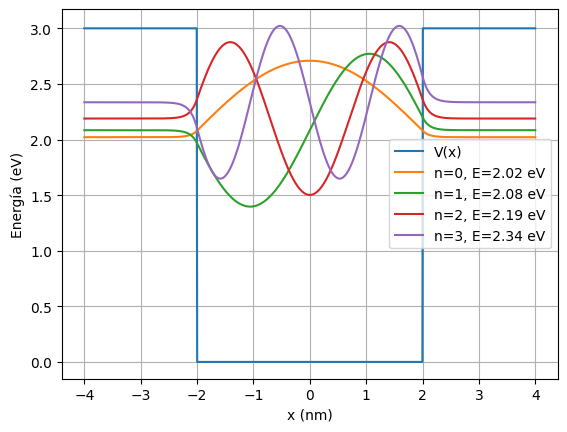

In [22]:
### PLOTEAR RESULTADOS ####################################33


plt.plot(x, V, label="V(x)")

for n in range(4):
    plt.plot(x, psi[:,n]+E[n], label=f"n={n}, E={E[n]:.3} eV")
    

plt.xlabel("x (nm)")
plt.ylabel("Energía (eV)")
plt.legend()
plt.grid()
plt.show()
